In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Load Airline Delay Cause dataset
df = pd.read_csv("Airline_Delay_Cause.csv")


In [3]:
df = df.copy()

# Binary target: 1 if there were any arrivals delayed 15+ minutes, else 0
df["Delayed"] = (df["arr_del15"] > 0).astype(int)

# Drop rows with missing target
df = df.dropna(subset=["Delayed"])

# Drop rows with missing key predictors
feature_cols = [
    "year",
    "month",
    "carrier",
    "airport",
    "arr_flights",
    "arr_cancelled",
    "arr_diverted",
    "arr_delay",
    "carrier_ct",
    "weather_ct",
    "nas_ct",
    "security_ct",
    "late_aircraft_ct",
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

df = df.dropna(subset=feature_cols)

X = df[feature_cols]
y = df["Delayed"]

X.head(), y.value_counts(normalize=True)


(   year  month carrier airport  arr_flights  arr_cancelled  arr_diverted  \
 0  2022      5      9E     ABE        136.0            0.0           0.0   
 1  2022      5      9E     ABY         91.0            0.0           0.0   
 2  2022      5      9E     ACK         19.0            1.0           0.0   
 3  2022      5      9E     AEX         88.0            0.0           0.0   
 4  2022      5      9E     AGS        181.0            0.0           0.0   
 
    arr_delay  carrier_ct  weather_ct  nas_ct  security_ct  late_aircraft_ct  \
 0      255.0        5.95        0.00    0.05          0.0              1.00   
 1      884.0        7.38        0.00    2.54          0.0              6.09   
 2      138.0        0.13        0.00    1.00          0.0              0.88   
 3      947.0        7.26        0.76    4.35          0.0              1.64   
 4      808.0       13.84        0.00    3.07          0.0              2.09   
 
    carrier_delay  weather_delay  nas_delay  security_

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Load Airline Delay Cause dataset
df = pd.read_csv("Airline_Delay_Cause.csv")

# Binary target: 1 if there were any arrivals delayed 15+ minutes, else 0
df["Delayed"] = (df["arr_del15"] > 0).astype(int)

# Drop rows with missing target
df = df.dropna(subset=["Delayed"])

# Drop rows with missing key predictors
feature_cols = [
    "year",
    "month",
    "carrier",
    "airport",
    "arr_flights",
    "arr_cancelled",
    "arr_diverted",
    "arr_delay",
    "carrier_ct",
    "weather_ct",
    "nas_ct",
    "security_ct",
    "late_aircraft_ct",
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

df = df.dropna(subset=feature_cols)

X = df[feature_cols]
y = df["Delayed"]

X.head(), y.value_counts(normalize=True)


(   year  month carrier airport  arr_flights  arr_cancelled  arr_diverted  \
 0  2022      5      9E     ABE        136.0            0.0           0.0   
 1  2022      5      9E     ABY         91.0            0.0           0.0   
 2  2022      5      9E     ACK         19.0            1.0           0.0   
 3  2022      5      9E     AEX         88.0            0.0           0.0   
 4  2022      5      9E     AGS        181.0            0.0           0.0   
 
    arr_delay  carrier_ct  weather_ct  nas_ct  security_ct  late_aircraft_ct  \
 0      255.0        5.95        0.00    0.05          0.0              1.00   
 1      884.0        7.38        0.00    2.54          0.0              6.09   
 2      138.0        0.13        0.00    1.00          0.0              0.88   
 3      947.0        7.26        0.76    4.35          0.0              1.64   
 4      808.0       13.84        0.00    3.07          0.0              2.09   
 
    carrier_delay  weather_delay  nas_delay  security_

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [6]:
numeric_features = [
    "year",
    "month",
    "arr_flights",
    "arr_cancelled",
    "arr_diverted",
    "arr_delay",
    "carrier_ct",
    "weather_ct",
    "nas_ct",
    "security_ct",
    "late_aircraft_ct",
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

categorical_features = ["carrier", "airport"]

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [7]:
log_reg = LogisticRegression(max_iter=5000, solver="lbfgs")
rf_clf = RandomForestClassifier(random_state=42)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", log_reg)
    ]
)

param_grid = [
    {
        "classifier": [log_reg],
        "classifier__C": np.logspace(-2, 2, 5),
        "classifier__penalty": ["l2"]
    },
    {
        "classifier": [rf_clf],
        "classifier__n_estimators": [100, 300],
        "classifier__max_depth": [None, 10, 20],
        "classifier__max_features": ["sqrt", "log2"]
    }
]

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

best_model = grid_search.fit(X_train, y_train)
best_model.best_params_, best_model.best_score_


Fitting 5 folds for each of 17 candidates, totalling 85 fits


({'classifier': RandomForestClassifier(random_state=42),
  'classifier__max_depth': None,
  'classifier__max_features': 'sqrt',
  'classifier__n_estimators': 100},
 1.0)

In [8]:
# Training performance
y_train_pred = best_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", round(train_acc, 3))

# Test performance
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", round(test_acc, 3))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

Training Accuracy: 1.0
Test Accuracy: 1.0

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2745
           1       1.00      1.00      1.00     92506

    accuracy                           1.00     95251
   macro avg       1.00      1.00      1.00     95251
weighted avg       1.00      1.00      1.00     95251



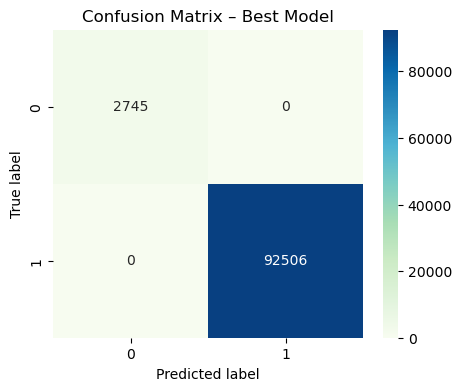

In [9]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="GnBu")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Best Model")
plt.savefig('figure_Confusion_Matrix_Best_Model.png', dpi=300, bbox_inches='tight')
plt.show()

ROC AUC: 1.0


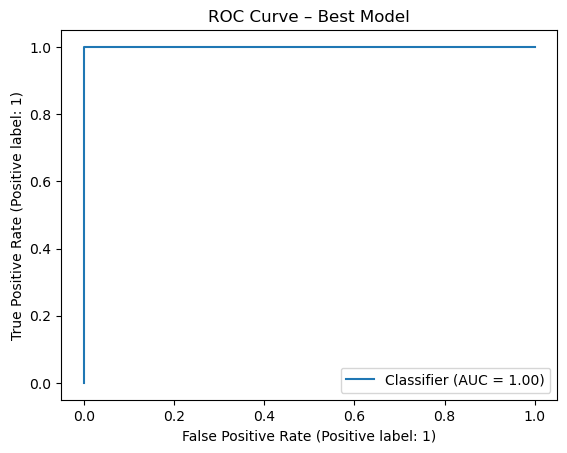

In [10]:
best_est = best_model.best_estimator_

if hasattr(best_est.named_steps["classifier"], "predict_proba"):
    y_test_proba = best_est.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_test_proba)
    print("ROC AUC:", round(auc, 3))

    RocCurveDisplay.from_predictions(y_test, y_test_proba)
    plt.title("ROC Curve – Best Model")
    plt.savefig('figure_ROC_Curve_Best_Model.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Selected classifier does not support predict_proba.")

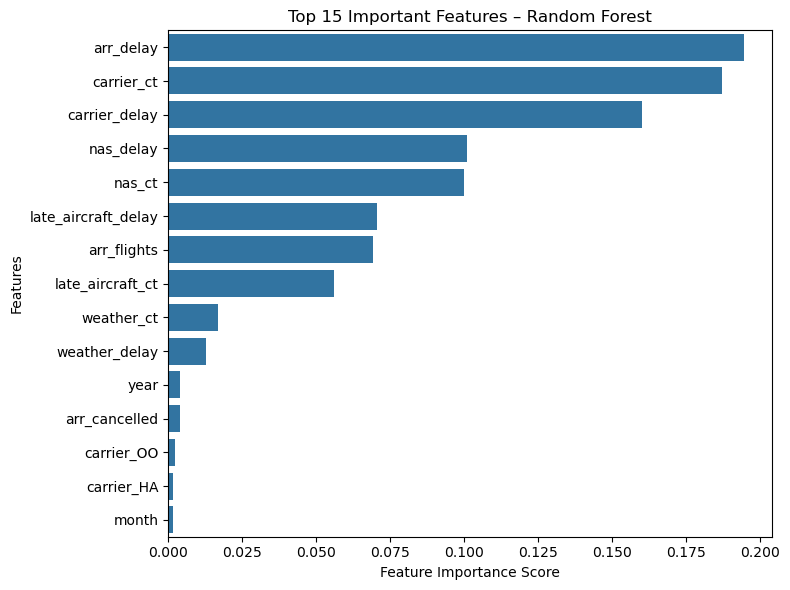

In [11]:
# Get the best estimator
best_est = best_model.best_estimator_

# Extract the classifier inside the pipeline
best_clf = best_est.named_steps["classifier"]

if isinstance(best_clf, RandomForestClassifier):
    # Get the one-hot encoder from the preprocessing step
    ohe = best_est.named_steps["preprocess"].named_transformers_["cat"]["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features)

    # Combine numeric + categorical feature names
    all_feature_names = np.concatenate([numeric_features, cat_feature_names])

    # Extract feature importances
    importances = best_clf.feature_importances_
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

    # Plot top 15
    plt.figure(figsize=(8,6))
    sns.barplot(x=feat_imp.head(15), y=feat_imp.head(15).index)
    plt.xlabel("Feature Importance Score")
    plt.ylabel("Features")
    plt.title("Top 15 Important Features – Random Forest")
    plt.tight_layout()
    plt.savefig('figure_randomforrest_important_features.png', dpi=300, bbox_inches='tight')
    plt.show()

    feat_imp.head(15)
else:
    print("Best model is not a RandomForestClassifier; skipping feature importance plot.")

In [12]:
best_model.best_estimator_.named_steps["classifier"]

RandomForestClassifier(random_state=42)

In [13]:
# Extract and save top-15 feature importances (run after grid search)
import pandas as pd
import numpy as np

best_clf = best_est.named_steps['classifier']

# Only proceed if RandomForest was selected
if hasattr(best_clf, 'feature_importances_'):
    # Get categorical feature names from the one-hot encoder
    ohe = best_est.named_steps['preprocess'].named_transformers_['cat']['onehot']
    cat_feature_names = ohe.get_feature_names_out(['carrier','airport'])
    
    # Numeric feature names must match the order used in the ColumnTransformer
    numeric_features = [
        'year','month','arr_flights','arr_cancelled','arr_diverted','arr_delay',
        'carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct',
        'carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay'
    ]
    
    # Combine numeric + categorical names
    all_feature_names = np.concatenate([numeric_features, cat_feature_names])
    
    # Get importances and build DataFrame
    importances = best_clf.feature_importances_
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
    
    # Top 15
    top15 = feat_imp.head(15).reset_index()
    top15.columns = ['feature', 'importance']
    top15['importance'] = top15['importance'].round(6)
    
    # Save CSV for Word
    top15.to_csv('top15_feature_importances.csv', index=False)
    
    # Print compact table for quick copy/paste
    print(top15.to_string(index=False))
else:
    print("Best estimator does not expose feature_importances_.")


            feature  importance
          arr_delay    0.194326
         carrier_ct    0.187108
      carrier_delay    0.159982
          nas_delay    0.101032
             nas_ct    0.099819
late_aircraft_delay    0.070505
        arr_flights    0.069022
   late_aircraft_ct    0.056006
         weather_ct    0.016796
      weather_delay    0.012644
               year    0.003909
      arr_cancelled    0.003863
         carrier_OO    0.002472
         carrier_HA    0.001706
              month    0.001487


In [14]:
# Cell A Load data and create target
import pandas as pd
df = pd.read_csv("Airline_Delay_Cause.csv")
df['Delayed'] = (df['arr_del15'] > 0).astype(int)
print("Raw rows:", len(df))
df.head()


Raw rows: 318017


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,Delayed
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,0.05,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0,1
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,2.54,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0,1
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,1.00,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0,1
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,4.35,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0,1
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,3.07,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0,1


In [16]:
# Cell B Define columns to keep, drop NA, and show sample
cols = [
    'year','month','carrier','airport','arr_flights','arr_cancelled','arr_diverted',
    'arr_delay','carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct',
    'carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay','Delayed'
]
# Keep only columns that exist in your file (safe subset)
cols = [c for c in cols if c in df.columns]
df_clean = df[cols].dropna().reset_index(drop=True)
print("Cleaned rows:", len(df_clean))
display(df_clean.head(10))


Cleaned rows: 317501


,year,month,carrier,airport,arr_flights,arr_cancelled,arr_diverted,arr_delay,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,Delayed
0,2022,5,9E,ABE,136.0,0.0,0.0,255.0,5.95,0.00,0.05,0.0,1.00,222.0,0.0,4.0,0.0,29.0,1
1,2022,5,9E,ABY,91.0,0.0,0.0,884.0,7.38,0.00,2.54,0.0,6.09,351.0,0.0,81.0,0.0,452.0,1
2,2022,5,9E,ACK,19.0,1.0,0.0,138.0,0.13,0.00,1.00,0.0,0.88,4.0,0.0,106.0,0.0,28.0,1
3,2022,5,9E,AEX,88.0,0.0,0.0,947.0,7.26,0.76,4.35,0.0,1.64,585.0,35.0,125.0,0.0,202.0,1
4,2022,5,9E,AGS,181.0,0.0,0.0,808.0,13.84,0.00,3.07,0.0,2.09,662.0,0.0,87.0,0.0,59.0,1
5,2022,5,9E,ALB,134.0,5.0,0.0,917.0,4.42,1.00,6.48,0.0,6.09,224.0,78.0,398.0,0.0,217.0,1
6,2022,5,9E,ATL,3042.0,2.0,3.0,38397.0,142.96,13.53,106.98,0.0,189.53,20775.0,1205.0,3610.0,0.0,12807.0,1
7,2022,5,9E,ATW,118.0,0.0,0.0,914.0,4.83,0.00,6.85,0.0,1.32,578.0,0.0,171.0,0.0,165.0,1
8,2022,5,9E,AUS,53.0,1.0,0.0,582.0,5.23,1.00,0.89,0.0,0.88,445.0,20.0,19.0,0.0,98.0,1
9,2022,5,9E,AVL,58.0,1.0,0.0,996.0,4.54,0.00,7.61,0.0,1.85,290.0,0.0,618.0,0.0,88.0,1


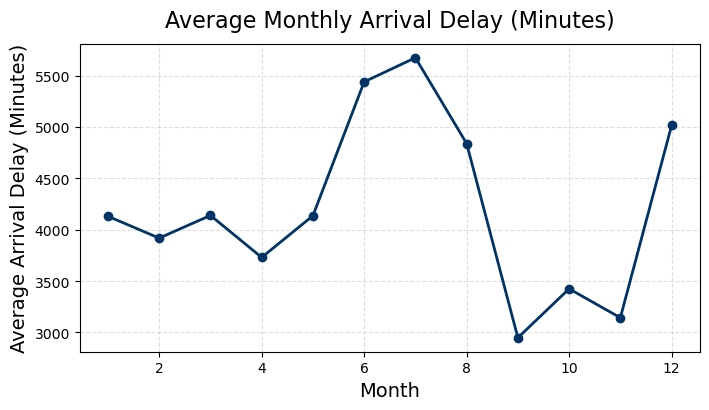

In [18]:
monthly_trend = df.groupby("month")["arr_delay"].mean()

ax = monthly_trend.plot(
    kind="line",
    figsize=(8, 4),
    color="#003366",
    linewidth=2,
    marker="o"
)

ax.set_title("Average Monthly Arrival Delay (Minutes)", fontsize=16, pad=12)
ax.set_xlabel("Month", fontsize=14)
ax.set_ylabel("Average Arrival Delay (Minutes)", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

# Optional: ensure months appear in order if month is a string
# ax.set_xticks(range(1, 13))



In [23]:
# Title for your slide/table
print("Top 10 Airports by Delay Frequency\n")

airport_delay = (
    df.groupby("airport")
      .agg(
          delay_rate=("Delayed", "mean"),
          avg_delay_minutes=("arr_delay", "mean"),
          months_observed=("Delayed", "count")
      )
      .assign(
          delay_rate=lambda x: (x["delay_rate"] * 100).round(2).astype(str) + "%",
          avg_delay_minutes=lambda x: x["avg_delay_minutes"].round(2)
      )
      .sort_values("delay_rate", ascending=False)
      .head(10)
)

airport_delay


Top 10 Airports by Delay Frequency



,delay_rate,avg_delay_minutes,months_observed
airport,,,
HNL,99.88%,3861.95,1605
SFO,99.82%,16140.16,2704
SNA,99.73%,2570.05,2203
ASE,99.63%,4695.66,270
ACV,99.56%,3253.91,228
CDV,99.56%,588.56,228
BET,99.56%,572.25,228
SEA,99.52%,7646.30,2686
EWN,99.5%,868.98,199


In [ ]:
# Example placeholder for Prophet
model = Prophet()
model.fit(df_prophet)
